## Preparación

Importamos las librerías y fijamos la semilla para que los resultados sean reproducibles.

Solo usamos librerías que ya están en el proyecto: NumPy, pandas, matplotlib, scikit-learn y PyTorch.

In [1]:
import re
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
pd.set_option("display.max_colwidth", 120)

print("Listo. Versiones:", f"pandas {pd.__version__}", f"torch {torch.__version__}", sep="\n  ")

Listo. Versiones:
  pandas 3.0.3
  torch 2.14.1+cu130


---
# Parte 0. Los datos: SMS spam

Usaremos el **SMS Spam Collection**, un dataset público con 5,572 mensajes de texto en **inglés**, cada uno etiquetado como:

- `ham`: mensaje normal (de amigos, familia, trabajo).
- `spam`: publicidad no deseada, premios falsos, suscripciones...

Es el problema clásico de las diapositivas: un **filtro de spam**. Los mensajes están escritos como se escribe un SMS real, con abreviaturas (`u` = *you*, `ur` = *your*, `txt` = *text*), faltas y números de teléfono: un buen ejemplo de la "variación" que vimos al hablar de por qué el lenguaje es difícil (diapositiva 5).

In [2]:
DATA_PATH = Path(r"C:\Users\SAHUA\Documents\datascience-g8\01-python-intro\data\spam.csv")

df_crudo = pd.read_csv(DATA_PATH)
df_crudo.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std t...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"


## Ejercicio 1. Conoce el dataset

Antes de modelar, siempre hay que mirar los datos. Calcula:

a) `n_mensajes`: el número total de mensajes.

b) `n_spam`: cuántos mensajes son spam.

c) `pct_spam`: el porcentaje de spam (de 0 a 100).

d) `n_duplicados`: cuántas filas están **repetidas** exactamente (pista: `df.duplicated()`).

e) `mediana_largo`: un diccionario con la **mediana del número de caracteres** del mensaje para cada clase, por ejemplo `{"ham": ..., "spam": ...}`. Pista: `df["Message"].str.len()` y `groupby`.

**Solución**

In [3]:
n_mensajes = len(df_crudo)
n_spam = (df_crudo["Category"] == "spam").sum()
pct_spam = 100 * n_spam / n_mensajes
n_duplicados = df_crudo.duplicated().sum()
mediana_largo = df_crudo["Message"].str.len().groupby(df_crudo["Category"]).median().to_dict()

print(f"Mensajes: {n_mensajes} | spam: {n_spam} ({pct_spam:.1f}%) | duplicados: {n_duplicados}")
print("Mediana de caracteres por clase:", mediana_largo)

Mensajes: 5572 | spam: 747 (13.4%) | duplicados: 415
Mediana de caracteres por clase: {'ham': 52.0, 'spam': 149.0}


**Para analizar**

1. ¿Las clases están balanceadas? Si un modelo respondiera siempre `ham`, ¿qué exactitud (*accuracy*) tendría?
2. ¿Por qué conviene **eliminar los duplicados** antes de separar los datos en entrenamiento y prueba?

**Respuesta:** 
1. No: solo ~13% es spam. Un modelo que siempre dice `ham` acertaría ~87% de las veces sin haber aprendido nada. Por eso la exactitud no basta y necesitamos precisión, recall y F1.
2. Si un mismo mensaje queda en entrenamiento **y** en prueba, el modelo se evalúa con algo que ya "memorizó" y las métricas salen infladas. Es una forma de fuga de datos (*data leakage*).

### Datos listos para el resto del notebook

Esta celda ya está resuelta: elimina duplicados, crea la etiqueta numérica (`1` = spam, `0` = ham) y separa **80% entrenamiento / 20% prueba**. Con `stratify` ambas partes mantienen la misma proporción de spam.

In [4]:
df = df_crudo.drop_duplicates().reset_index(drop=True)
df["spam"] = (df["Category"] == "spam").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    df["Message"], df["spam"], test_size=0.2, stratify=df["spam"], random_state=SEED
)

print(f"Sin duplicados: {len(df)} mensajes")
print(f"Entrenamiento: {len(X_train)} | Prueba: {len(X_test)} (spam en prueba: {y_test.sum()})")

Sin duplicados: 5157 mensajes
Entrenamiento: 4125 | Prueba: 1032 (spam en prueba: 128)


---
# Parte 1. NLP clásico

## Ejercicio 2. Preprocesado paso a paso

Reproduce en código el **Ejercicio 1 de la presentación**: limpiar la frase

> "Los gatos estaban corriendo rápidamente por el jardín."

a) `tokens`: tokeniza la frase, separando palabras **y** signos de puntuación. Pista: `re.findall(r"\w+|[^\w\s]", frase)` encuentra secuencias de letras (`\w+`) o un símbolo que no es letra ni espacio (`[^\w\s]`).

b) `minusculas`: pasa a minúsculas y quita la puntuación (quédate solo con los tokens que son palabras; pista: `token.isalpha()`).

c) `sin_stopwords`: elimina las palabras de la lista `STOPWORDS_ES`.

d) `lemas`: reemplaza cada palabra por su lema usando el diccionario `LEMAS`. Si una palabra no está en el diccionario, déjala igual (pista: `LEMAS.get(palabra, palabra)`).

In [5]:
frase = "Los gatos estaban corriendo rápidamente por el jardín."
STOPWORDS_ES = {"los", "el", "la", "por", "de", "estaban"}
LEMAS = {"gatos": "gato", "corriendo": "correr", "estudiantes": "estudiante", "corrieron": "correr"}

**Solución**

In [6]:
tokens = re.findall(r"\w+|[^\w\s]", frase)
minusculas = [t.lower() for t in tokens if t.isalpha()]
sin_stopwords = [t for t in minusculas if t not in STOPWORDS_ES]
lemas = [LEMAS.get(t, t) for t in sin_stopwords]

for paso, resultado in [("a) Tokens", tokens), ("b) Minúsculas", minusculas),
                        ("c) Sin stopwords", sin_stopwords), ("d) Lemas", lemas)]:
    print(f"{paso:<17} ({len(resultado)}): {resultado}")

a) Tokens         (9): ['Los', 'gatos', 'estaban', 'corriendo', 'rápidamente', 'por', 'el', 'jardín', '.']
b) Minúsculas     (8): ['los', 'gatos', 'estaban', 'corriendo', 'rápidamente', 'por', 'el', 'jardín']
c) Sin stopwords  (4): ['gatos', 'corriendo', 'rápidamente', 'jardín']
d) Lemas          (4): ['gato', 'correr', 'rápidamente', 'jardín']


### Extra: un stemmer de juguete

El *stemming* recorta terminaciones con reglas fijas, sin diccionario. Programa `stem()` para que, si la palabra termina en alguno de los sufijos de la lista `SUFIJOS`, se lo quite (prueba los sufijos **en el orden de la lista** y quita solo el primero que coincida).

In [7]:
SUFIJOS = ["iendo", "ieron", "antes", "os", "as", "es", "s"]

**Solución**

In [8]:
def stem(palabra):
    for sufijo in SUFIJOS:
        if palabra.endswith(sufijo):
            return palabra[: -len(sufijo)]
    return palabra


for palabra in ["corriendo", "corrieron", "estudiantes", "gatos", "fui"]:
    print(f"{palabra:<12} → {stem(palabra)}")

corriendo    → corr
corrieron    → corr
estudiantes  → estudi
gatos        → gat
fui          → fui


**Para analizar:** compara los *stems* con los lemas. ¿Qué ventaja y qué desventaja tiene el stemming frente a la lematización?

**Respuesta:** El stemming es simple y rápido (solo reglas, sin diccionario) y agrupa variantes como "corriendo" y "corrieron" en "corr". Pero el resultado no siempre es una palabra real ("estudi") y no resuelve formas irregulares: "fui" queda igual, mientras que un lematizador sabría que viene de "ir" o "ser".

## Ejercicio 3. Tokenizar y limpiar los SMS

Ahora aplicamos el preprocesado a los mensajes reales, que están en inglés.

a) Programa `tokenizar(texto)`: pasa el texto a minúsculas y devuelve la lista de tokens formados por letras, números o apóstrofes. Pista: `re.findall(r"[a-z0-9']+", texto.lower())`.

b) Programa `limpiar(texto)`: tokeniza y elimina las *stopwords* en inglés (`ENGLISH_STOP_WORDS`, de scikit-learn) y los tokens de **un solo carácter**.

c) Con `limpiar()`, cuenta las palabras de todos los mensajes de cada clase del DataFrame `df` y guarda las **10 más frecuentes** en `top_spam` y `top_ham` (pista: `Counter(...).most_common(10)`).

**Solución**

In [9]:
def tokenizar(texto):
    return re.findall(r"[a-z0-9']+", texto.lower())


def limpiar(texto):
    return [t for t in tokenizar(texto) if t not in ENGLISH_STOP_WORDS and len(t) > 1]


top_spam = Counter(t for m in df.loc[df["spam"] == 1, "Message"] for t in limpiar(m)).most_common(10)
top_ham = Counter(t for m in df.loc[df["spam"] == 0, "Message"] for t in limpiar(m)).most_common(10)

ejemplo = "Free entry in 2 a wkly comp! Text WIN to 87121"
print("tokenizar:", tokenizar(ejemplo))
print("limpiar:  ", limpiar(ejemplo))
print("\nSpam:", top_spam)
print("Ham: ", top_ham)

tokenizar: ['free', 'entry', 'in', '2', 'a', 'wkly', 'comp', 'text', 'win', 'to', '87121']
limpiar:   ['free', 'entry', 'wkly', 'comp', 'text', 'win', '87121']

Spam: [('free', 190), ('txt', 132), ('ur', 119), ('stop', 110), ('text', 108), ('mobile', 105), ('reply', 96), ('claim', 94), ('www', 81), ('prize', 78)]
Ham:  [("i'm", 370), ('gt', 288), ('lt', 287), ('just', 282), ('ok', 254), ('got', 227), ('know', 226), ('like', 224), ('good', 217), ('come', 214)]


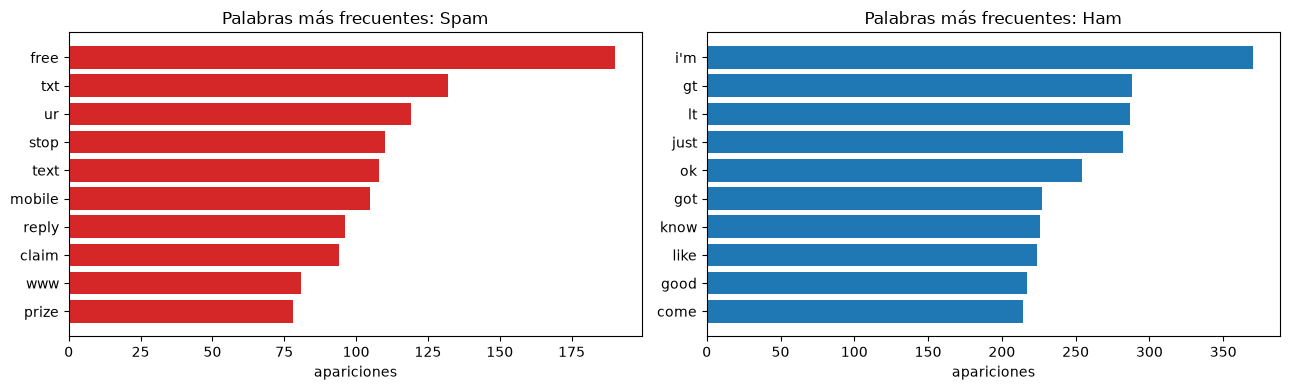

In [10]:
# Visualización (ya resuelta): palabras más frecuentes por clase
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (titulo, top, color) in zip(axes, [("Spam", top_spam, "tab:red"), ("Ham", top_ham, "tab:blue")]):
    palabras, conteos = zip(*top)
    ax.barh(palabras[::-1], conteos[::-1], color=color)
    ax.set_title(f"Palabras más frecuentes: {titulo}")
    ax.set_xlabel("apariciones")
plt.tight_layout()
plt.show()

**Para analizar**

1. ¿Qué palabras delatan al spam? ¿Tienen sentido?
2. En `ham` aparecen `lt` y `gt`. Busca un mensaje que las contenga (`df[df["Message"].str.contains("&lt;")]`). ¿Qué son?
3. Revisa si `"not"`, `"no"` y `"call"` están en `ENGLISH_STOP_WORDS` (por ejemplo, `"call" in ENGLISH_STOP_WORDS`). ¿Sería un problema quitar "not" si estuviéramos detectando **sentimiento**? ¿Y quitar "call" para detectar spam?

**Respuesta:** 1. `free`, `txt`, `claim`, `prize`, `cash`, `mobile`, `stop`, `reply`: son palabras de ofertas, premios y suscripciones. Tienen todo el sentido para un filtro de spam.
2. Son restos de HTML: `&lt;#&gt;` es la forma codificada de `<#>`, un marcador que reemplazó números en los mensajes originales. Es "ruido" del dataset; un buen preprocesado podría eliminarlo.
3. Las tres están en la lista. En sentimiento, quitar "not" sería grave: "not good" quedaría como "good" (diapositiva 10: "no" es clave para el sentimiento). Y "call" es justamente una de las palabras que **más** delatan al spam ("call now to claim..."): lo veremos en el ejercicio 10. Las listas de stopwords son genéricas; las decisiones de preprocesado dependen de la tarea.

## Ejercicio 4. Bolsa de palabras

a) Programa `bolsa_de_palabras(documentos)` para reproducir la tabla de la diapositiva:

- Tokeniza cada documento separando por espacios (`doc.split()`).
- El vocabulario son **todas las palabras distintas, en orden alfabético**.
- La matriz tiene una fila por documento y una columna por palabra, con el **número de veces** que aparece cada palabra.

Devuelve `(vocabulario, matriz)`, con la matriz como arreglo de NumPy.

In [11]:
DOCS = ["me gusta el cine", "me gusta el teatro y el cine", "odio el teatro"]

**Solución**

In [12]:
def bolsa_de_palabras(documentos):
    tokens_por_doc = [doc.split() for doc in documentos]
    vocabulario = sorted({t for tokens in tokens_por_doc for t in tokens})
    matriz = np.array([[tokens.count(palabra) for palabra in vocabulario] for tokens in tokens_por_doc])
    return vocabulario, matriz


vocabulario, matriz = bolsa_de_palabras(DOCS)
print(pd.DataFrame(matriz, columns=vocabulario, index=["D1", "D2", "D3"]))

    cine  el  gusta  me  odio  teatro  y
D1     1   1      1   1     0       0  0
D2     1   2      1   1     0       1  1
D3     0   1      0   0     1       1  0


b) Ahora usa `CountVectorizer` de scikit-learn, que hace lo mismo automáticamente. Ejecuta la celda y compara con tu tabla: **falta una palabra**. ¿Cuál y por qué?

Pista: por defecto, `CountVectorizer` usa `token_pattern=r"(?u)\b\w\w+\b"`, que solo acepta tokens de **2 o más** caracteres. Crea `vectorizador_ok` con `token_pattern=r"(?u)\b\w+\b"` para que la matriz coincida con la tuya.

**Solución**

In [13]:
vectorizador = CountVectorizer()
matriz_sklearn = vectorizador.fit_transform(DOCS).toarray()
print("Por defecto:", vectorizador.get_feature_names_out())

vectorizador_ok = CountVectorizer(token_pattern=r"(?u)\b\w+\b")
matriz_ok = vectorizador_ok.fit_transform(DOCS).toarray()
print("Corregido: ", vectorizador_ok.get_feature_names_out())
print(matriz_ok)

Por defecto: ['cine' 'el' 'gusta' 'me' 'odio' 'teatro']
Corregido:  ['cine' 'el' 'gusta' 'me' 'odio' 'teatro' 'y']
[[1 1 1 1 0 0 0]
 [1 2 1 1 0 1 1]
 [0 1 0 0 1 1 0]]


c) La bolsa de palabras **pierde el orden**. Compruébalo: con `vectorizador_ok`, transforma las frases `"el perro muerde al hombre"` y `"el hombre muerde al perro"` y guarda en `mismo_vector` si ambos vectores son idénticos (`True` o `False`).

Atención: usa `.transform()` (no `.fit_transform()`), así las frases se representan con el vocabulario ya aprendido. Pregúntate qué pasa con las palabras que no estaban en ese vocabulario.

**Solución**

In [14]:
v1, v2 = vectorizador_ok.transform(["el perro muerde al hombre", "el hombre muerde al perro"]).toarray()
mismo_vector = bool((v1 == v2).all())
print(v1, v2, mismo_vector)

[0 1 0 0 0 0 0] [0 1 0 0 0 0 0] True


**Para analizar:** en el punto c), los vectores son idénticos, pero además casi todos sus valores son 0. ¿Por qué? ¿Qué problema del enfoque clásico ilustra esto (diapositiva 28)?

**Respuesta:** Solo "el" estaba en el vocabulario de los tres documentos: "perro", "muerde", "al" y "hombre" son palabras **desconocidas** y se ignoran. Ilustra dos limitaciones: se pierde el orden (sujeto y objeto quedan iguales) y el vocabulario es fijo, así que las palabras nuevas desaparecen. Con vocabularios reales, además, los vectores son enormes y casi todos ceros (dispersos).

## Ejercicio 5. N-gramas y un modelo de lenguaje (diapositivas 15 a 17)

a) Programa `ngramas(tokens, n)`: devuelve la lista de n-gramas como **cadenas** separadas por espacio. Por ejemplo, `ngramas(["no", "me", "gusta"], 2)` → `["no me", "me gusta"]`.

b) Programa `prob_bigrama(corpus, anterior, palabra)` con la fórmula del modelo de bigramas:

$$P(\text{palabra} \mid \text{anterior}) = \frac{C(\text{anterior palabra})}{C(\text{anterior})}$$

donde `corpus` es una lista de frases, `C(anterior palabra)` cuenta cuántas veces aparece ese bigrama y `C(anterior)` cuántas veces aparece la palabra `anterior`.

c) Calcula `p_secuencia`: la probabilidad de "yo como pan" partiendo de "yo" (diapositiva 17).

In [15]:
CORPUS = ["yo como pan", "yo como fruta", "tú comes pan"]

**Solución**

In [16]:
def ngramas(tokens, n):
    return [" ".join(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]


def prob_bigrama(corpus, anterior, palabra):
    bigramas = [b for frase in corpus for b in ngramas(frase.split(), 2)]
    palabras = [t for frase in corpus for t in frase.split()]
    return bigramas.count(f"{anterior} {palabra}") / palabras.count(anterior)


p_secuencia = prob_bigrama(CORPUS, "yo", "como") * prob_bigrama(CORPUS, "como", "pan")

frase_ej = "me gusta mucho el cine".split()
print("Bigramas: ", ngramas(frase_ej, 2))
print("Trigramas:", ngramas(frase_ej, 3))
print(f"P(como | yo) = {prob_bigrama(CORPUS, 'yo', 'como')}")
print(f"P(pan | como) = {prob_bigrama(CORPUS, 'como', 'pan')}")
print(f"P(yo como pan) = {p_secuencia}")

Bigramas:  ['me gusta', 'gusta mucho', 'mucho el', 'el cine']
Trigramas: ['me gusta mucho', 'gusta mucho el', 'mucho el cine']
P(como | yo) = 1.0
P(pan | como) = 0.5
P(yo como pan) = 0.5


d) Los bigramas también sirven como **características** para clasificar. Usa `ngram_range` en `CountVectorizer` para contar **solo bigramas** en los mensajes de spam y ver los más frecuentes.

**Solución**

In [17]:
vectorizador_bigramas = CountVectorizer(ngram_range=(2, 2), stop_words="english")

conteos = vectorizador_bigramas.fit_transform(df.loc[df["spam"] == 1, "Message"])
frecuencias = pd.Series(np.asarray(conteos.sum(axis=0)).ravel(),
                        index=vectorizador_bigramas.get_feature_names_out())
frecuencias.sort_values(ascending=False).head(10)

po box               21
send stop            19
prize guaranteed     19
urgent mobile        17
1000 cash            17
national rate        17
txt stop             16
selected receive     16
land line            16
account statement    15
dtype: int64

**Para analizar:** ¿los bigramas (`prize guaranteed`, `po box`, `urgent mobile`...) dan más información que las palabras sueltas? ¿Qué problema aparece si usamos trigramas o 4-gramas (diapositiva 15)?

**Respuesta:** Sí: "prize guaranteed" o "send stop" son mucho más específicos del spam que "prize" o "stop" por separado, porque capturan algo del orden local. Pero al aumentar n el vocabulario crece muchísimo y la mayoría de n-gramas aparece una sola vez (datos dispersos): el modelo no tiene suficientes ejemplos de cada uno.

## Ejercicio 6. TF-IDF a mano (diapositivas 18 a 20)

Implementa las fórmulas de la diapositiva 18. `docs` es una lista de documentos ya tokenizados (listas de palabras).

- `tf(t, doc)` = veces que aparece `t` en `doc` / número de palabras de `doc`
- `idf(t, docs)` = log₁₀( N / df(t) ), donde N es el número de documentos y df(t) en cuántos aparece `t`. Pista: `np.log10`.
- `tfidf(t, doc, docs)` = tf × idf

Luego reproduce el **Ejercicio 3 de la presentación**: `tfidf_teatro_d2`, `tfidf_el_d2` y `tfidf_odio_d3`.

**Solución**

In [ ]:
DOCS

In [ ]:
DOCS_TOKENS = [doc.split() for doc in DOCS]


def tf(t, doc):
    return doc.count(t) / len(doc)


def idf(t, docs):
    df_t = sum(1 for doc in docs if t in doc)
    return np.log10(len(docs) / df_t)


def tfidf(t, doc, docs):
    return tf(t, doc) * idf(t, docs)


d1, d2, d3 = DOCS_TOKENS
tfidf_teatro_d2 = tfidf("teatro", d2, DOCS_TOKENS)
tfidf_el_d2 = tfidf("el", d2, DOCS_TOKENS)
tfidf_odio_d3 = tfidf("odio", d3, DOCS_TOKENS)

for nombre, valor in [("teatro, D2", tfidf_teatro_d2), ("el, D2", tfidf_el_d2), ("odio, D3", tfidf_odio_d3)]:
    print(f"tfidf({nombre}) = {valor:.3f}")

### Comparación con scikit-learn

`TfidfVectorizer` calcula TF-IDF automáticamente, pero con **dos diferencias** respecto a la fórmula de la diapositiva:

1. Usa un idf **suavizado**: `idf = ln((1 + N) / (1 + df)) + 1`. Así ninguna palabra queda con peso exactamente 0.
2. **Normaliza** cada fila para que el vector tenga longitud 1 (norma L2), de modo que los documentos largos no tengan ventaja.

Ejecuta la celda y observa: los valores no coinciden con los nuestros, pero el **orden** de importancia se mantiene: en D3, "odio" pesa más que "teatro", y "teatro" más que "el".

In [ ]:
vectorizador_tfidf = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b")
tabla_tfidf = pd.DataFrame(vectorizador_tfidf.fit_transform(DOCS).toarray(),
                           columns=vectorizador_tfidf.get_feature_names_out(), index=["D1", "D2", "D3"])
tabla_tfidf.round(3)

## Ejercicio 7. Naive Bayes (diapositivas 22 a 24)

a) Reproduce el **Ejercicio 4 de la presentación**: ¿es spam "gratis oferta reunión"? Usa las probabilidades del diccionario `P` y P(clase) = 0.5 para ambas clases. Calcula `puntuacion_spam`, `puntuacion_normal` y `prob_spam` (la puntuación de spam normalizada).

In [ ]:
P = {
    "spam":   {"gratis": 3 / 12, "oferta": 3 / 12, "reunión": 1 / 12},
    "normal": {"gratis": 1 / 12, "oferta": 1 / 12, "reunión": 3 / 12},
}
mensaje = ["gratis", "oferta", "reunión"]

**Solución**

In [ ]:
puntuacion_spam = 0.5 * np.prod([P["spam"][w] for w in mensaje])
puntuacion_normal = 0.5 * np.prod([P["normal"][w] for w in mensaje])
prob_spam = puntuacion_spam / (puntuacion_spam + puntuacion_normal)

print(f"Puntuación spam:   {puntuacion_spam:.5f}")
print(f"Puntuación normal: {puntuacion_normal:.5f}")
print(f"P(spam | mensaje) = {prob_spam:.2f}")

b) Ahora calcula probabilidades **reales** con el suavizado de Laplace de la diapositiva 22:

$$P(w \mid c) = \frac{C(w, c) + 1}{\text{palabras de } c + |V|}$$

Programa `prob_laplace(conteo, total_palabras_clase, tam_vocabulario)`. La celda siguiente (ya resuelta) la usa con los mensajes de entrenamiento para ver cuánto más probable es cada palabra en spam que en ham.

**Solución**

In [ ]:
def prob_laplace(conteo, total_palabras_clase, tam_vocabulario):
    return (conteo + 1) / (total_palabras_clase + tam_vocabulario)

In [ ]:
# Ya resuelto: conteos de palabras por clase en el set de entrenamiento
contador = CountVectorizer()
X_conteos = contador.fit_transform(X_train)
vocab_idx = contador.vocabulary_
conteo_spam = np.asarray(X_conteos[y_train.values == 1].sum(axis=0)).ravel()
conteo_ham = np.asarray(X_conteos[y_train.values == 0].sum(axis=0)).ravel()
tam_vocab = len(vocab_idx)

filas = []
for palabra in ["free", "win", "call", "love", "home", "tomorrow", "meeting"]:
    i = vocab_idx[palabra]
    p_spam = prob_laplace(conteo_spam[i], conteo_spam.sum(), tam_vocab)
    p_ham = prob_laplace(conteo_ham[i], conteo_ham.sum(), tam_vocab)
    filas.append({"palabra": palabra, "P(w | spam)": p_spam, "P(w | ham)": p_ham, "spam / ham": p_spam / p_ham})

pd.DataFrame(filas).set_index("palabra").round(5)

**Para analizar:** interpreta la columna `spam / ham`. ¿Qué palabras empujan hacia spam y cuáles hacia ham? ¿Qué pasaría con la multiplicación de Naive Bayes si una palabra nunca apareció en spam y **no** usáramos suavizado?

**Respuesta:** Un cociente mayor que 1 empuja hacia spam: "free" y "win" son muchas veces más probables en spam. Un cociente menor que 1 empuja hacia ham: "love", "home" o "tomorrow" son típicas de mensajes personales. Sin suavizado, una palabra nunca vista en spam tendría P(w | spam) = 0, y como Naive Bayes **multiplica** probabilidades, todo el mensaje quedaría con probabilidad 0 de ser spam, por muy "spam" que fuera el resto.

## Ejercicio 8. Métricas de evaluación (diapositivas 25 a 27)

Reproduce el **Ejercicio 5 de la presentación**. Un filtro evaluado con 100 correos obtuvo VP = 40, FP = 10, FN = 20 y VN = 30. Calcula `exactitud`, `precision`, `recall` y `f1` con las fórmulas de la diapositiva 25.

In [ ]:
VP, FP, FN, VN = 40, 10, 20, 30

**Solución**

In [ ]:
exactitud = (VP + VN) / (VP + FP + FN + VN)
precision = VP / (VP + FP)
recall = VP / (VP + FN)
f1 = 2 * precision * recall / (precision + recall)

print(f"Exactitud: {exactitud:.2f} | Precisión: {precision:.2f} | Recall: {recall:.2f} | F1: {f1:.2f}")

**Para analizar:** si lo peor para el usuario es **perder un correo importante** en la carpeta de spam, ¿qué métrica vigilarías? ¿Y si lo peor es que le llegue spam?

**Respuesta:** Perder un correo importante es un **falso positivo** (un correo normal marcado como spam), así que hay que vigilar la **precisión**. Si lo peor es que se cuele spam (falsos negativos), vigilamos el **recall**. Mejorar una suele empeorar la otra: siempre hay un compromiso, y F1 resume el equilibrio.

## Ejercicio 9. Tu primer filtro de spam con scikit-learn (diapositiva 53)

Entrena dos clasificadores clásicos con `make_pipeline`, como en la diapositiva 53:

- `modelo_nb`: `CountVectorizer()` + `MultinomialNB()` (el clásico de los filtros de spam).
- `modelo_lr`: `TfidfVectorizer(ngram_range=(1, 2))` + `LogisticRegression(max_iter=1000)`.

Para cada uno: entrena con `X_train, y_train` (`.fit`) y predice sobre `X_test` (`.predict`), guardando las predicciones en `pred_nb` y `pred_lr`. Mide también el tiempo de entrenamiento de cada modelo con `time.time()`.

Por último, calcula `exactitud_tonto`: la exactitud de un "modelo" que predice **siempre 0** (ham) sobre `y_test`.

**Solución**

In [ ]:
modelo_nb = make_pipeline(CountVectorizer(), MultinomialNB())
modelo_lr = make_pipeline(TfidfVectorizer(ngram_range=(1, 2)), LogisticRegression(max_iter=1000))

inicio = time.time()
modelo_nb.fit(X_train, y_train)
pred_nb = modelo_nb.predict(X_test)
tiempo_nb = time.time() - inicio

inicio = time.time()
modelo_lr.fit(X_train, y_train)
pred_lr = modelo_lr.predict(X_test)
tiempo_lr = time.time() - inicio

exactitud_tonto = accuracy_score(y_test, np.zeros(len(y_test)))

Esta celda (ya resuelta) resume las métricas de ambos modelos y dibuja sus matrices de confusión.

In [ ]:
def resumen_metricas(y_real, y_pred):
    return {"exactitud": accuracy_score(y_real, y_pred), "precisión": precision_score(y_real, y_pred),
            "recall": recall_score(y_real, y_pred), "F1": f1_score(y_real, y_pred)}


resultados = pd.DataFrame({
    "Siempre ham": {"exactitud": exactitud_tonto, "precisión": 0, "recall": 0, "F1": 0},
    "Naive Bayes": resumen_metricas(y_test, pred_nb),
    "TF-IDF + Reg. logística": resumen_metricas(y_test, pred_lr),
}).T
display(resultados.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (nombre, pred) in zip(axes, [("Naive Bayes", pred_nb), ("TF-IDF + Reg. logística", pred_lr)]):
    ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["ham", "spam"],
                                            ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(nombre)
plt.tight_layout()
plt.show()

**Para analizar**

1. El modelo "siempre ham" tiene una exactitud muy alta. ¿Por qué es un modelo inútil? ¿Qué métrica lo delata?
2. Compara precisión y recall de la regresión logística. ¿Qué tipo de error comete: deja pasar spam o bloquea mensajes normales?
3. ¿Cuál de los dos modelos preferirías para un filtro real? Justifica con las métricas.

**Respuesta:** 1. Acierta ~88% solo porque la mayoría de mensajes son ham, pero no detecta ningún spam: su recall y su F1 son 0. Con clases desbalanceadas, la exactitud engaña.
2. La regresión logística tiene precisión 1.0 (nunca marca como spam un mensaje normal) pero recall ~0.71: deja pasar casi un 30% del spam. Es un modelo muy "conservador".
3. Naive Bayes tiene el mejor F1 (~0.92): detecta mucho más spam a costa de muy pocos falsos positivos. Si bloquear un mensaje normal fuera inaceptable, la regresión logística sería una opción, pero habría que mejorar su recall (por ejemplo, con `class_weight="balanced"` o bajando el umbral de decisión).

## Ejercicio 10. ¿Qué aprendió el modelo? Interpretación y errores (diapositivas 21 y 51)

Una ventaja del NLP clásico es su **interpretabilidad**: la regresión logística aprende **un peso por palabra** (o bigrama). Pesos positivos empujan hacia spam y negativos hacia ham.

Obtén `top_spam_lr`: los **15 términos con mayor peso** (los más "spam") y `top_ham_lr`: los **15 con menor peso**. Pista: `np.argsort(pesos)` devuelve los índices ordenados de menor a mayor.

**Solución**

In [ ]:
terminos = modelo_lr.named_steps["tfidfvectorizer"].get_feature_names_out()
pesos = modelo_lr.named_steps["logisticregression"].coef_[0]

orden = np.argsort(pesos)
top_spam_lr = list(terminos[orden[::-1][:15]])
top_ham_lr = list(terminos[orden[:15]])

print("Más spam:", top_spam_lr)
print("Más ham: ", top_ham_lr)

Ahora miremos los **errores** de Naive Bayes en el set de prueba (celda ya resuelta):

- **Falsos positivos**: mensajes normales que el filtro marcó como spam.
- **Falsos negativos**: spam que se coló.

In [ ]:
errores = pd.DataFrame({"mensaje": X_test.values, "real": y_test.values, "predicho": pred_nb})
falsos_positivos = errores[(errores["real"] == 0) & (errores["predicho"] == 1)]
falsos_negativos = errores[(errores["real"] == 1) & (errores["predicho"] == 0)]

print(f"Falsos positivos ({len(falsos_positivos)}): mensajes normales marcados como spam")
display(falsos_positivos[["mensaje"]])
print(f"\nFalsos negativos ({len(falsos_negativos)}): spam que se coló (primeros 8)")
display(falsos_negativos[["mensaje"]].head(8))

**Para analizar**

1. Entre los términos con más peso aparecen palabras como "to", "your", "from" (hacia spam) o "me", "my", "it" (hacia ham), que son *stopwords*. ¿Qué nos dice esto sobre eliminarlas siempre?
2. Lee los falsos positivos y algunos falsos negativos. ¿Qué tienen en común? ¿Por qué crees que el modelo se equivocó?

**Respuesta:** 1. Que las stopwords también llevan información de **estilo**: el spam le habla al lector ("your", "call to", "from"), y los mensajes personales hablan de uno mismo ("me", "my"). Como aquí no las eliminamos, el modelo pudo aprovecharlas. Eliminar stopwords no siempre mejora un modelo.
2. Los falsos positivos son mensajes normales **cortos** con vocabulario de telefonía o de ofertas: "FREE SMS", "Unlimited texts. Limited minutes", "airtel line". Los falsos negativos son spam redactado como un **mensaje personal** ("Oh my god! I've found your number again!", "Hello darling how are you today?"), sin las palabras delatoras. Una bolsa de palabras no entiende la intención, solo cuenta palabras: si el spam imita el vocabulario de un amigo, se cuela. También aparece un mensaje `#ERROR!`: una fila dañada del dataset, que ningún modelo puede clasificar bien.

---
# Parte 2. NLP con redes neuronales

## Ejercicio 11. Una neurona a mano (diapositivas 30 a 32)

a) Programa `sigmoide(z)` = 1 / (1 + e⁻ᶻ) (pista: `np.exp`) y `relu(z)` = max(0, z) (pista: `np.maximum`).

b) Programa `neurona(x, w, b)`: calcula z = w · x + b (producto escalar, pista: `np.dot`) y devuelve `sigmoide(z)`.

c) Reproduce el **Ejercicio 6 de la presentación**: calcula `y_A` e `y_B` para las frases A = (1, 0, 1) y B = (0, 1, 1).

In [ ]:
w = np.array([2, -3, 1])     # pesos de "genial", "aburrida", "película"
b = -1                       # sesgo
x_A = np.array([1, 0, 1])
x_B = np.array([0, 1, 1])

**Solución**

In [ ]:
def sigmoide(z):
    return 1 / (1 + np.exp(-z))


def relu(z):
    return np.maximum(0, z)


def neurona(x, w, b):
    z = np.dot(w, x) + b
    return sigmoide(z)


y_A = neurona(x_A, w, b)
y_B = neurona(x_B, w, b)
print(f"Frase A: y = {y_A:.3f} → {'positiva' if y_A > 0.5 else 'negativa'}")
print(f"Frase B: y = {y_B:.3f} → {'positiva' if y_B > 0.5 else 'negativa'}")

In [ ]:
# Visualización (ya resuelta): las tres activaciones de la diapositiva 30
z = np.linspace(-5, 5, 200)
plt.figure(figsize=(8, 4))
plt.plot(z, sigmoide(z), label="sigmoide (0 a 1)")
plt.plot(z, np.tanh(z), label="tanh (-1 a 1)")
plt.plot(z, relu(z), label="ReLU (0 a ∞)")
plt.axhline(0, color="gray", lw=0.5)
plt.axvline(0, color="gray", lw=0.5)
plt.ylim(-1.5, 3)
plt.legend()
plt.title("Funciones de activación")
plt.show()

**Para analizar:** en la frase B la palabra "película" (peso +1) suma a favor, pero el resultado es negativo. ¿Por qué? ¿Qué representan los pesos en esta neurona?

**Respuesta:** Porque el peso de "aburrida" (−3) es mucho más fuerte que el de "película" (+1): z = −3 + 1 − 1 = −3 y la sigmoide da ≈ 0.05. Cada peso indica **cuánto y en qué dirección** influye cada palabra en la decisión; en una red real, esos pesos no se escriben a mano: se aprenden con los datos.

## Ejercicio 12. Similitud coseno (diapositivas 36 a 38)

a) Programa `similitud_coseno(a, b)` = a · b / (|a| · |b|). Pistas: `np.dot` y `np.linalg.norm`.

b) Reproduce el **Ejercicio 7 de la presentación** con los embeddings de juguete: calcula `cos_gato_perro`, `cos_gato_coche` y `cos_perro_coche`.

In [ ]:
gato = np.array([1, 2, 0])
perro = np.array([2, 3, 1])
coche = np.array([0, 1, 4])

**Solución**

In [ ]:
def similitud_coseno(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


cos_gato_perro = similitud_coseno(gato, perro)
cos_gato_coche = similitud_coseno(gato, coche)
cos_perro_coche = similitud_coseno(perro, coche)
print(f"cos(gato, perro) = {cos_gato_perro:.2f}")
print(f"cos(gato, coche) = {cos_gato_coche:.2f}")
print(f"cos(perro, coche) = {cos_perro_coche:.2f}")

## Ejercicio 13. Embeddings aprendidos de los SMS (diapositivas 34 y 35)

La **hipótesis distribucional** dice que una palabra se conoce por las palabras que la acompañan. Vamos a comprobarlo construyendo embeddings a partir de los propios SMS, sin redes neuronales:

1. Para cada palabra, contamos qué palabras aparecen **cerca** de ella (a una distancia de hasta 2 posiciones). Así cada palabra se describe por su fila en una **matriz de co-ocurrencias**.
2. Ajustamos los conteos con **PPMI**, que baja el peso de las palabras que aparecen cerca de todo (misma idea que el IDF).
3. Comprimimos cada fila a **50 números** con `TruncatedSVD`. Ese vector denso es el **embedding** de la palabra.

Word2Vec llega a un resultado parecido de otra forma (adivinando palabras con una red neuronal), pero la idea de fondo es la misma. La celda siguiente ya está resuelta; tarda unos segundos.

In [ ]:
# 1. Vocabulario: palabras que aparecen al menos 5 veces en los SMS
docs_tokens = [re.findall(r"[a-z0-9']+", m.lower()) for m in df["Message"]]
frecuencia = Counter(t for doc in docs_tokens for t in doc)
vocab_emb = [t for t, c in frecuencia.items() if c >= 5]
indice = {t: i for i, t in enumerate(vocab_emb)}

# 2. Matriz de co-ocurrencias con una ventana de 2 palabras a cada lado
VENTANA = 2
coocurrencias = np.zeros((len(vocab_emb), len(vocab_emb)))
for doc in docs_tokens:
    for i, palabra in enumerate(doc):
        if palabra not in indice:
            continue
        for j in range(max(0, i - VENTANA), min(len(doc), i + VENTANA + 1)):
            if j != i and doc[j] in indice:
                coocurrencias[indice[palabra], indice[doc[j]]] += 1

# 3. PPMI: ¿aparecen juntas más de lo que esperaríamos por azar?
total = coocurrencias.sum()
p_fila = coocurrencias.sum(axis=1, keepdims=True) / total
p_col = coocurrencias.sum(axis=0, keepdims=True) / total
with np.errstate(divide="ignore", invalid="ignore"):
    pmi = np.log((coocurrencias / total) / (p_fila * p_col))
ppmi = np.nan_to_num(np.maximum(pmi, 0))

# 4. Comprimir a 50 dimensiones: cada fila es el embedding de una palabra
embeddings = TruncatedSVD(n_components=50, random_state=SEED).fit_transform(ppmi)

print(f"Vocabulario: {len(vocab_emb)} palabras | embeddings de forma {embeddings.shape}")
print("Embedding de 'free' (primeros 8 valores):", embeddings[indice["free"], :8].round(2))

Programa `mas_parecidas(palabra, n)`: devuelve las `n` palabras del vocabulario con **mayor similitud coseno** con `palabra`, **sin incluir la propia palabra**. Usa tu función `similitud_coseno` del ejercicio anterior.

Pista: calcula la similitud de `embeddings[indice[palabra]]` con cada fila de `embeddings`, ordena con `np.argsort` y toma los índices de mayor a menor.

**Solución**

In [ ]:
def mas_parecidas(palabra, n=6):
    vector = embeddings[indice[palabra]]
    similitudes = np.array([similitud_coseno(vector, otro) for otro in embeddings])
    orden = np.argsort(similitudes)[::-1]
    return [vocab_emb[i] for i in orden if vocab_emb[i] != palabra][:n]


for palabra in ["dinner", "prize", "tomorrow", "love", "free"]:
    print(f"{palabra:<9} → {mas_parecidas(palabra)}")

**Para analizar:** ¿los vecinos tienen sentido? Nadie le dijo al modelo que "dinner" y "lunch" son comidas: ¿cómo lo "descubrió"? Prueba con otras palabras del vocabulario (por ejemplo `"sorry"`, `"happy"`, `"cash"`).

**Respuesta:** Sí: "dinner" queda cerca de "lunch", "prize" cerca de "bonus", "guaranteed" y "cash", y "tomorrow" cerca de "today" o "time". El modelo lo descubrió solo porque esas palabras aparecen en **contextos parecidos** ("have lunch/dinner with...", "claim your prize/cash..."). Esa es la hipótesis distribucional. Con un corpus tan pequeño algunos vecinos son ruidosos; con millones de textos (Word2Vec, GloVe) los embeddings son mucho mejores.

## Ejercicio 14. Una RNN diminuta (diapositivas 39 a 42)

a) Programa `paso_rnn(h_anterior, x, w=0.5, u=1.0)`, que aplica la fórmula del **Ejercicio 8 de la presentación**: hₜ = tanh(w · hₜ₋₁ + u · xₜ). Pista: `np.tanh`.

b) Calcula `h1` y `h2` con h₀ = 0, x₁ = 1 y x₂ = 0.5.

c) Ahora una secuencia más larga: la primera entrada es 1 y las 9 siguientes son 0. Guarda en la lista `estados` los 10 estados ocultos h₁ ... h₁₀ (empieza con h = 0 y aplica `paso_rnn` a cada entrada).

**Solución**

In [ ]:
def paso_rnn(h_anterior, x, w=0.5, u=1.0):
    return np.tanh(w * h_anterior + u * x)


h1 = paso_rnn(0, 1)
h2 = paso_rnn(h1, 0.5)
print(f"h1 = {h1:.3f} | h2 = {h2:.3f}")

secuencia = [1] + [0] * 9
estados = []
h = 0
for x in secuencia:
    h = paso_rnn(h, x)
    estados.append(h)
print("Estados:", np.round(estados, 4))

In [ ]:
# Visualización (ya resuelta): ¿cuánto "recuerda" la RNN de la primera palabra?
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), estados, "o-", label="w = 0.5")
estados_09 = []
h = 0
for x in secuencia:
    h = paso_rnn(h, x, w=0.9)
    estados_09.append(h)
plt.plot(range(1, 11), estados_09, "s-", label="w = 0.9")
plt.xlabel("paso (palabra)")
plt.ylabel("estado oculto h")
plt.title("La huella de la primera palabra se desvanece")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Para analizar:** ¿qué pasa con la información de la primera palabra a medida que avanza la secuencia? ¿Qué relación tiene esto con el problema de la frase "Los libros que me prestó mi prima la semana pasada en Madrid ___ muy interesantes" (diapositiva 42)?

**Respuesta:** Se desvanece: en cada paso el estado anterior se multiplica por w (y pasa por tanh), así que tras unas pocas palabras la huella de x₁ es casi 0. Con w = 0.9 dura algo más, pero también se apaga. Por eso una RNN simple "olvida" que el sujeto era "libros" doce palabras atrás. Las LSTM y GRU añaden **puertas** que deciden qué conservar, para que la memoria dure más.

## Ejercicio 15. Atención con softmax (diapositivas 44 a 46)

a) Programa `softmax(s)` = eˢⁱ / Σⱼ eˢʲ. Truco numérico: resta el máximo antes de exponenciar (`np.exp(s - s.max())`); el resultado es el mismo y evita desbordamientos.

b) Reproduce el **Ejercicio 9 de la presentación**: calcula `pesos_atencion` aplicando softmax a las puntuaciones, y `salida_atencion` como la suma de pesos × V (pista: `pesos @ V`).

In [ ]:
puntuaciones = np.array([1.0, 3.0, 0.0])        # Q·K con "el", "gato", "duerme"
V = np.array([[1, 0], [0, 1], [1, 1]])          # valores de cada palabra

**Solución**

In [ ]:
def softmax(s):
    s = np.asarray(s, dtype=float)
    e = np.exp(s - s.max())
    return e / e.sum()


pesos_atencion = softmax(puntuaciones)
salida_atencion = pesos_atencion @ V
print("Pesos:", pesos_atencion.round(3), "| suman", pesos_atencion.sum())
print("Salida:", salida_atencion.round(3))

c) Generaliza a la fórmula completa de la diapositiva 44:

$$\text{Atención}(Q, K, V) = \text{softmax}\left(\frac{Q K^\top}{\sqrt{d}}\right) V$$

Programa `atencion(Q, K, V)`, donde cada fila de Q, K y V corresponde a una palabra y `d` es el número de columnas de K. Devuelve `(salida, pesos)`, donde `pesos` es la matriz de atención (una fila por palabra, cada fila suma 1). Aplica tu `softmax` **fila por fila** (pista: `np.apply_along_axis(softmax, 1, matriz)`).

In [ ]:
# Autoatención de juguete: 3 palabras, vectores de dimensión 2
palabras_frase = ["el", "gato", "duerme"]
Q = np.array([[1.0, 0.0], [0.0, 2.0], [1.0, 1.0]])
K = np.array([[1.0, 0.0], [0.0, 2.0], [1.0, 1.0]])
V_frase = np.array([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]])

**Solución**

In [ ]:
def atencion(Q, K, V):
    d = K.shape[1]
    puntuaciones = Q @ K.T / np.sqrt(d)
    pesos = np.apply_along_axis(softmax, 1, puntuaciones)
    return pesos @ V, pesos


salida, pesos = atencion(Q, K, V_frase)
print(pd.DataFrame(pesos, index=palabras_frase, columns=palabras_frase).round(3))

**Para analizar:** en la tabla de pesos, cada fila indica a qué palabras "mira" cada palabra. ¿Qué diferencia fundamental hay entre esto y la RNN del ejercicio anterior (piensa en palabras lejanas y en velocidad)?

**Respuesta:** En la atención, **cada palabra mira directamente a todas las demás** en un solo paso, sin importar la distancia: no hay un estado que se vaya desvaneciendo. Además, todas las filas se calculan a la vez con multiplicaciones de matrices, así que se puede paralelizar. La RNN, en cambio, procesa palabra a palabra y la información lejana llega diluida. Estas son las dos ventajas del Transformer (diapositiva 47).

## Ejercicio 16. Una red neuronal para detectar spam (diapositivas 33 y 34)

Ahora entrenamos una red neuronal de verdad con PyTorch. La arquitectura es sencilla:

```
mensaje → tokens → ids → [Embedding] → promedio de los vectores → [Linear] → puntuación → sigmoide → P(spam)
```

- **`nn.Embedding`**: una tabla con un vector de 32 números por palabra. Empieza al azar y **se aprende** durante el entrenamiento (igual que los pesos).
- **Promedio**: resume el mensaje en un solo vector (como una bolsa de palabras, pero con embeddings densos).
- **`nn.Linear`**: una neurona que da la puntuación final.

La preparación de datos y el modelo ya están escritos. Lee los comentarios y ejecuta las celdas.

In [ ]:
# 1. Vocabulario (solo con el set de entrenamiento): palabras que aparecen al menos 2 veces
def tokens_sms(texto):
    return re.findall(r"[a-z0-9']+", texto.lower())   # misma tokenización del ejercicio 3


contador_train = Counter(t for m in X_train for t in tokens_sms(m))
vocab = {"<pad>": 0, "<desconocida>": 1}
for palabra, conteo in contador_train.items():
    if conteo >= 2:
        vocab[palabra] = len(vocab)

# 2. Cada mensaje se convierte en una lista fija de 40 ids (se recorta o se rellena con 0)
LARGO = 40


def codificar(texto):
    ids = [vocab.get(t, 1) for t in tokens_sms(texto)][:LARGO]
    return ids + [0] * (LARGO - len(ids))


X_train_ids = torch.tensor([codificar(m) for m in X_train])
X_test_ids = torch.tensor([codificar(m) for m in X_test])
y_train_t = torch.tensor(y_train.values, dtype=torch.float32)

print(f"Vocabulario: {len(vocab)} palabras")
print("Mensaje:", X_train.iloc[0])
print("Ids:    ", X_train_ids[0].tolist())

In [ ]:
class ClasificadorSpam(nn.Module):
    def __init__(self, n_vocab, dim=32):
        super().__init__()
        self.embedding = nn.Embedding(n_vocab, dim, padding_idx=0)   # un vector por palabra
        self.salida = nn.Linear(dim, 1)                              # una neurona final

    def forward(self, x):
        vectores = self.embedding(x)                                 # [batch, 40, 32]
        mascara = (x != 0).unsqueeze(-1).float()                     # ignoramos el relleno (id 0)
        promedio = (vectores * mascara).sum(dim=1) / mascara.sum(dim=1).clamp(min=1)
        return self.salida(promedio).squeeze(-1)                     # puntuación (logit)


torch.manual_seed(SEED)
red = ClasificadorSpam(len(vocab))
criterio = nn.BCEWithLogitsLoss()                  # pérdida para clasificación binaria
optimizador = torch.optim.Adam(red.parameters(), lr=1e-2)
cargador = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_train_ids, y_train_t),
                                       batch_size=64, shuffle=True)
print(red)
print(f"Parámetros: {sum(p.numel() for p in red.parameters()):,}")

Escribe el **bucle de entrenamiento** con los 4 pasos de la diapositiva 33 (antes, limpia los gradientes con `optimizador.zero_grad()`):

1. **Predecir** (forward): `puntuaciones = red(x_lote)`
2. **Medir el error**: `perdida = criterio(puntuaciones, y_lote)`
3. **Repartir la culpa** (backpropagation): `perdida.backward()`
4. **Ajustar** los pesos: `optimizador.step()`

Después, en la evaluación, calcula `pred_red`: 1 si la probabilidad (sigmoide de la puntuación) es mayor que 0.5 y 0 en caso contrario, como arreglo de NumPy.

**Solución**

In [ ]:
EPOCAS = 10
inicio = time.time()

for epoca in range(1, EPOCAS + 1):
    red.train()
    perdida_total = 0.0
    for x_lote, y_lote in cargador:
        optimizador.zero_grad()
        puntuaciones = red(x_lote)                  # 1. predecir
        perdida = criterio(puntuaciones, y_lote)    # 2. medir el error
        perdida.backward()                          # 3. repartir la culpa
        optimizador.step()                          # 4. ajustar

        perdida_total += perdida.item() * len(y_lote)
    print(f"Época {epoca:>2} | pérdida: {perdida_total / len(y_train_t):.4f}")

tiempo_red = time.time() - inicio

red.eval()
with torch.no_grad():
    puntuaciones_test = red(X_test_ids)
    pred_red = (torch.sigmoid(puntuaciones_test) > 0.5).int().numpy()

In [ ]:
print(f"F1 de la red neuronal: {f1_score(y_test, pred_red):.3f}")

---
# Parte 3. Comparación y repaso

## Ejercicio 17. Clásico frente a neuronal (diapositivas 51 y 52)

Construye el DataFrame `comparacion` con una fila por modelo (**Naive Bayes**, **TF-IDF + Reg. logística** y **Red neuronal**) y las columnas `precisión`, `recall`, `F1` y `tiempo (s)`. Puedes reutilizar la función `resumen_metricas()` del ejercicio 9 y las variables `tiempo_nb`, `tiempo_lr` y `tiempo_red`.

**Solución**

In [ ]:
filas = {}
for nombre, pred, tiempo in [("Naive Bayes", pred_nb, tiempo_nb),
                             ("TF-IDF + Reg. logística", pred_lr, tiempo_lr),
                             ("Red neuronal", pred_red, tiempo_red)]:
    metricas = resumen_metricas(y_test, pred)
    filas[nombre] = {"precisión": metricas["precisión"], "recall": metricas["recall"],
                     "F1": metricas["F1"], "tiempo (s)": tiempo}

comparacion = pd.DataFrame(filas).T
comparacion.round(3)

**Para analizar**

1. ¿La red neuronal supera a Naive Bayes? ¿Qué dice el consejo de la diapositiva 52 sobre este resultado?
2. ¿Qué modelo es más fácil de **explicar** a un usuario que pregunta por qué su mensaje fue marcado como spam?
3. ¿En qué tipo de tarea esperarías que un modelo neuronal (por ejemplo, un Transformer preentrenado) sí marcara una gran diferencia?

**Respuesta:** 1. No: Naive Bayes (F1 ≈ 0.92), que se entrena en una fracción de segundo, supera a la red neuronal (F1 ≈ 0.89). La diapositiva 52 lo dice: "empieza siempre por una línea base clásica; si el modelo neuronal no la supera con claridad, no compensa". El spam es una tarea sencilla donde las palabras sueltas bastan.
2. Los modelos clásicos: Naive Bayes y la regresión logística tienen un peso (o probabilidad) por palabra, y se puede mostrar qué palabras empujaron hacia spam (ejercicio 10). La red mezcla todo en embeddings de 32 números, mucho más difíciles de interpretar.
3. En tareas donde importa el contexto y el significado: ironía, negaciones ("not bad at all"), traducción, resumen, preguntas y respuestas. Ahí una bolsa de palabras se queda corta y un Transformer preentrenado aporta mucho.

## Ejercicio 18. Preguntas de repaso (diapositiva 55)

Responde con tus palabras. Todas tienen relación con algún ejercicio de este notebook.

1. ¿Por qué TF-IDF da peso 0 a "el" en nuestro ejemplo? *(Ejercicio 6)*
2. ¿Qué problemas de los vectores one-hot resuelven los embeddings? *(Ejercicios 4 y 13)*
3. ¿Qué limita a una RNN simple con frases largas? *(Ejercicio 14)*
4. ¿Qué dos ventajas tiene el Transformer frente a la RNN? *(Ejercicio 15)*
5. Tienes 500 reseñas etiquetadas y un portátil sin GPU. ¿Qué pruebas primero y por qué? *(Ejercicio 17)*

**Respuesta:** 1. Porque "el" aparece en los 3 documentos: idf = log₁₀(3/3) = 0. Una palabra que está en todos los documentos no sirve para distinguirlos.
2. Los one-hot son enormes (una dimensión por palabra), casi todos ceros, y todas las palabras quedan igual de lejos entre sí. Los embeddings son densos y pequeños (50 a 300 números) y colocan cerca a las palabras parecidas ("dinner" y "lunch").
3. El gradiente que se desvanece: la información de las primeras palabras se diluye paso a paso (lo vimos en la gráfica). Además es lenta, porque procesa una palabra a la vez.
4. Procesa todas las palabras **en paralelo** (entrenamiento mucho más rápido) y la atención conecta **directamente** palabras lejanas, sin memoria que se desvanezca.
5. Primero una línea base clásica: TF-IDF + regresión logística (o Naive Bayes). Se entrena en segundos sin GPU y con pocos datos funciona bien. Después, si hace falta, un modelo preentrenado ya ajustado o un ajuste fino pequeño, comparando el F1 con la línea base.

---
## Para ir más allá (opcional)

**Un Transformer preentrenado.** La diapositiva 54 muestra cómo usar BERT con la librería `transformers` de Hugging Face. No viene instalada en el proyecto; si quieres probarla:

```bash
uv add transformers
```

```python
from transformers import pipeline

clasificador = pipeline("sentiment-analysis",
                        model="nlptown/bert-base-multilingual-uncased-sentiment")
print(clasificador("Me encantó la película"))
```

La primera ejecución descarga el modelo (varios cientos de MB).

**Mini-proyecto (diapositiva 57).** Repite los ejercicios 9 y 17 con un dataset de **reseñas en español** etiquetadas como positivas o negativas. Compara TF-IDF + regresión logística con un modelo preentrenado y analiza tres errores: ¿ironía, negación, vocabulario raro?